In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('Mall_Customers.csv')

df.info()
df=df.drop(columns=['CustomerID'])

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [3]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [4]:
km = KMeans(random_state=42)
df['Cluster'] = km.fit_predict(X_scaled)
print("Silhouette Score:", silhouette_score(X_scaled, df['Cluster']))

Silhouette Score: 0.37276475942129284


Variance explained: [0.33690046 0.26230645]


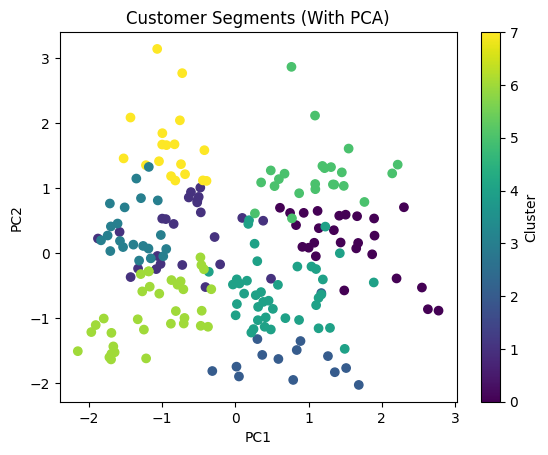

In [5]:
pca = PCA(n_components=2)  # reduce to 2D for visualization
X_pca = pca.fit_transform(X_scaled)

print("Variance explained:", pca.explained_variance_ratio_)  # how much info kept?

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['Cluster'],
    cmap='viridis'
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments (With PCA)')
plt.colorbar(label='Cluster')
plt.show()